# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [42]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [43]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [44]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [45]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [46]:
# revisar el número de filas y columnas de cada dataset
print('plans:', plans.shape)
print('users:', users.shape)
print('usage:', usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [47]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [48]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [49]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---
## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [50]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [51]:
# cantidad de nulos para usage
print(usage.isna().sum())        # Cantidad de valores nulos
print(usage.isna().mean())       # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
----------
Mi respuesta:

**Diagnóstico de valores nulos**

**users**

`city` – 469 nulos (11.7 %) - Dejar como nulo y marcar "Desconocida". Es un porcentaje moderado: eliminar esas filas haría perder casi el 12 % de los clientes, y no hay forma confiable de adivinar su ciudad.

`churn_date` – 3,534 nulos (88.4 %) - Ignorar (no imputar ni eliminar). Aunque supera el 80 %, aquí el nulo significa que el cliente sigue activo. La columna sirve para identificar a los clientes que se dieron de baja.

**usage**

`date` – 50 nulos (0.13 %) - Dejar como nulos. Es una proporción mínima y, para analizar el uso por usuario, la fecha no es indispensable, así que no conviene borrar esos eventos.

`duration` – 22,076 nulos (55.2 %) - Ignorar. Son estructurales nulos: corresponden a los mensajes (type = text) que no tienen duración.

`length` – 17,896 nulos (44.7 %) - Ignorar. Son nulos estructurales: corresponden a las llamadas (type = call), que no tienen longitud.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [52]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` va de 10000 a 13999, con 4000 valores. Es un identificador consecutivo, así que su resumen estadístico no tiene significado analítico; solo confirma que no hay IDs raros.
- La columna `age` tiene un mínimo de -999, una edad imposible. Es un sentinel que se usó para marcar edades desconocidas. Por esta razón, la media (33.7) queda muy por debajo de la mediana (47) y la desviación estándar se dispara a 123. Sin ese valor, las edades van de 18 a 79 y son razonables.

In [53]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son identificadores. id va de 1 a 40.000 y user_id de 10000 a 13999, el mismo rango que en users. No muestran problemas, y su media y desviación no tienen interpretación útil.
- Las columnas `duration` y `length` tienen máximos sospechosos:
`duration`: el 75 % de las llamadas dura 6.99 min o menos y la mediana es 3.5 min, pero el máximo es 120. Este valor está muy lejos del resto y se analiza como posible sentinel.
`length`: el 75 % de los mensajes tiene 64 caracteres o menos y la mediana es 50, pero el máximo es 1490. Es extremadamente alto para un SMS y también es un posible sentinel.
Ambas tienen como mínimo 0: llamadas sin duración y mensajes vacíos. Pueden ser llamadas no contestadas o errores de registro.
En ambas columnas la media es mayor que la mediana (5.2 vs 3.5 y 52.1 vs 50), lo que indica una distribución sesgada a la derecha por esos valores extremos.

In [54]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f'--- {col} ---')
    print(users[col].value_counts(dropna=False))
    print()

--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` tiene 6 ciudades válidas:
Colombia: Bogotá (808), Medellín (616) y Cali (424).
México: CDMX (730), GDL (450) y MTY (407).
También tiene 469 nulos (NaN) y 96 registros con "?". El "?" es un sentinel que significa "ciudad desconocida" y debe tratarse igual que un nulo. Además, las ciudades mexicanas están abreviadas mientras que las colombianas están escritas completas. No es un error, pero conviene tenerlo en cuenta al crear la columna de país.
- La columna `plan` solo tiene dos valores válidos, `Basico` (2,595) y `Premium` (1,405). Coinciden con los planes de `plans.csv` y no tienen errores, nulos ni variantes de escritura.

In [55]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` solo tiene dos valores válidos, `text` (22,092) y `call` (17,908), sin nulos ni categorías inesperadas. Los mensajes representan el 55 % de los eventos y las llamadas el 45 %. Esto coincide con los nulos de duration (22,076) y length (17,896) vistos en el punto 2.1, lo que confirma que esos nulos son estructurales.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

-----
---
✍️ **Diagnóstico – Valores inválidos o sentinels**

**¿En qué columnas encontraste valores inválidos o sentinels?**

| Dataset | Columna | Valor | Registros | Por qué es inválido |
|---|---|---|---|---|
| users | `age` | -999 | 55 | Edad negativa imposible; código para "edad desconocida". |
| users | `city` | `"?"` | 96 | Marcador de "ciudad desconocida", no es una ciudad real. |
| usage | `duration` | 120 | 30 | Muy lejos del resto (75 % ≤ 6.99 min) y se repite exactamente 30 veces. |
| usage | `length` | 1490 | 30 | Demasiado largo para un SMS (75 % ≤ 64 caracteres) y se repite exactamente 30 veces. |
| usage | `duration` / `length` | 0 | 15 / 133 | Llamadas sin duración y mensajes vacíos; sospechosos pero posibles. |

**¿Qué acción tomarías?**

- **`age = -999` → reemplazar por `NaN`**: así no distorsiona la media (33.7 vs mediana 47). No conviene imputar porque la edad es clave para segmentar.
- **`city = "?"` → reemplazar por `NaN`**: se unifica con los 469 nulos existentes y en el análisis por ciudad/país se agrupan como "Desconocida".
- **`duration = 120` → reemplazar por `NaN`**: no representa un uso real e inflaría el consumo promedio de minutos.
- **`length = 1490` → reemplazar por `NaN`**: no representa un uso real e inflaría la longitud promedio de los mensajes.
- **Valores en 0 → conservarlos**: pueden ser llamadas no contestadas o mensajes vacíos; son pocos y no sesgan el análisis. Se señalarán como posibles errores de registro en el análisis de outliers.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [56]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [57]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [58]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, los registros se distribuyen de forma muy pareja entre 2022 (1,314), 2023 (1,316) y 2024 (1,330). Sin embargo, aparecen 40 registros en el año 2026, lo cual es imposible porque los datos llegan solo hasta 2024. Estos 40 usuarios tienen exactamente la misma fecha (2026-05-10), lo que indica un error de captura o sentinel. Acción: reemplazar esas fechas por `NaT`, ya que no se puede saber su fecha real de registro. No hay años negativos ni fechas que no se puedan convertir.

In [59]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, todos los eventos válidos (39,950) pertenecen a 2024, entre enero y junio, así que no hay años futuros ni imposibles. Los 50 valores `NaN`corresponden a los nulos ya detectados en el punto 2.1, no a errores de conversión. Basaremos el análisis en estas fechas: el periodo de uso analizado es enero–junio 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

----
---
✍️ **Diagnóstico – Fechas fuera de rango**

**¿Aparecen años imposibles?**

- **`users.reg_date`**: **sí**. Hay 40 registros con año 2026, todos con la misma fecha (2026-05-10). Es imposible porque los datos solo llegan hasta 2024. Que todos tengan exactamente el mismo día indica un error de captura o un sentinel, no registros reales. No hay años demasiado antiguos ni negativos: el resto se reparte de forma pareja entre 2022 (1,314), 2023 (1,316) y 2024 (1,330).
- **`usage.date`**: **no**. Todos los eventos válidos (39,950) son de 2024 (enero–junio). Solo hay 50 nulos, que ya estaban vacíos en los datos originales, no fechas imposibles.

**¿Qué harías con ellas?**

- **`reg_date` con año 2026 → reemplazar por `NaT`**: no se puede saber la fecha real de registro, pero no conviene eliminar a esos 40 usuarios porque su edad, plan, ciudad y uso siguen siendo válidos para el análisis.
- **`date` nula en `usage` → dejar como `NaT`**: son solo el 0.13 % de los eventos, y la duración o longitud de esos eventos sigue siendo útil para analizar el consumo por usuario.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [60]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print('Mediana usada:', age_mediana)
users['age'].describe()

Mediana usada: 48.0


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [61]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print('Nulos en city:', users['city'].isna().sum())
users['city'].value_counts(dropna=False)

Nulos en city: 565


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [62]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print('Nulos en reg_date:', users['reg_date'].isna().sum())
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

Nulos en reg_date: 40


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [63]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [64]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---
**Diagnóstico de nulos en `duration` y `length`:**

- **`duration`**: el 0 % de las llamadas (`call`) tiene nulos, mientras que el 99.9 % de los mensajes (`text`) sí los tiene.
- **`length`**: el 0 % de los mensajes (`text`) tiene nulos, mientras que el 99.9 % de las llamadas (`call`) sí los tiene.

Los nulos **dependen completamente de la columna `type`**, por lo que son **MAR (Missing At Random)**: no faltan por error, sino porque la variable no aplica a ese tipo de evento (un mensaje no tiene duración y una llamada no tiene longitud).

**Decisión: dejarlos como nulos.** Imputarlos (por ejemplo, con la media) inventaría duraciones para mensajes y longitudes para llamadas, lo que distorsionaría el análisis. En los cálculos se analizará `duration` solo para llamadas y `length` solo para mensajes.

**Observación adicional:** existen 16 mensajes con `duration` y 12 llamadas con `length`, valores que no deberían existir según el tipo de evento. Son posibles errores de registro; al ser tan pocos (0.07 % del total), no afectan el análisis y se excluyen de forma natural al filtrar cada métrica por su tipo correspondiente.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [65]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum',
                                          'is_call': 'sum',
                                          'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [66]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes',
                                      'is_call': 'cant_llamadas',
                                      'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [67]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [68]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [69]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

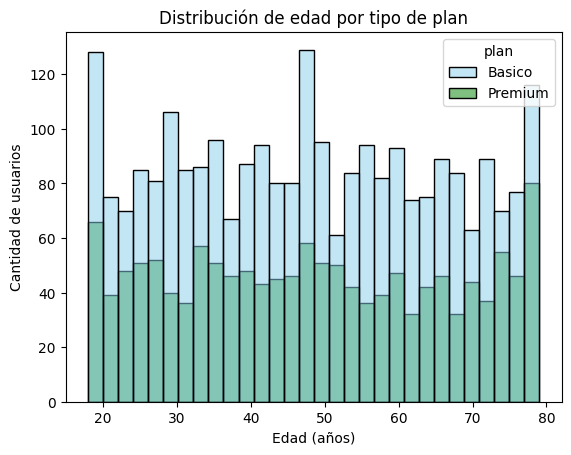

In [70]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=30)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
💡 Insights:
- **Distribución:** aproximadamente uniforme y simétrica entre 18 y 79 años; no hay una edad que concentre claramente a los clientes. Destaca un pico cerca de los 48 años, generado por la imputación de los 55 valores -999 con la mediana. Los picos en los extremos (18 y 79) se deben a que esos bins agrupan dos edades.
- **Por plan:** no existe un patrón claro por edad. Ambos planes tienen la misma forma en todo el rango y la barra Básico es más alta solo porque hay más clientes en ese plan (65 %). La proporción Premium se mantiene en ~35 % en todos los grupos de edad.

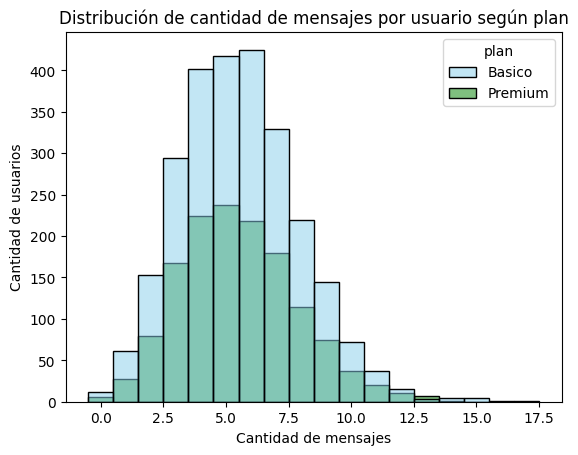

In [71]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], discrete=True)
plt.title('Distribución de cantidad de mensajes por usuario según plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **Distribución:** ligeramente sesgada a la derecha, con forma de campana. La mayoría de usuarios envía entre 3 y 8 mensajes (pico en 5–6) y la cola derecha se extiende hasta 17, con muy pocos usuarios por encima de 12.
- **Por plan:** no hay diferencia. Las dos distribuciones tienen la misma forma y el mismo pico; ambos planes promedian 5.5 mensajes por usuario en el periodo, aunque Premium incluye 5 veces más mensajes.

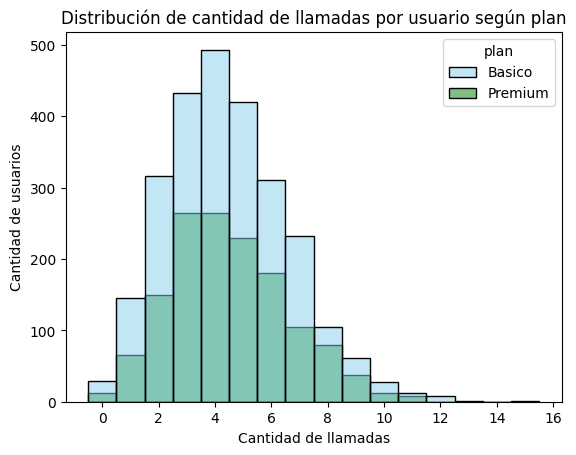

In [72]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], discrete=True)
plt.title('Distribución de cantidad de llamadas por usuario según plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **Distribución:** ligeramente sesgada a la derecha. El pico está en 3–4 llamadas, la mayoría hace entre 2 y 7, y muy pocos superan las 10 (máximo 15).
- **Por plan:** los usuarios Básico y Premium realizan en promedio 4.5 llamadas, con la misma forma de distribución. No existe un patrón que diferencie a los planes.

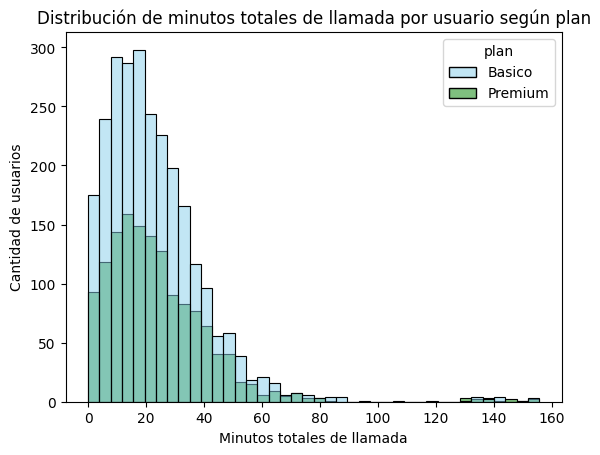

In [73]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=40)
plt.title('Distribución de minutos totales de llamada por usuario según plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **Distribución:** fuertemente sesgada a la derecha. La mayoría acumula entre 5 y 40 minutos (mediana: 19.8) y la frecuencia disminuye rápidamente después de 60 minutos.
- **Hallazgo clave:** se observa un grupo separado entre 130 y 155 minutos, aislado del resto por un hueco entre ~90 y 130. Estos usuarios no siguen la tendencia natural de la distribución: corresponden a quienes tienen llamadas con el sentinel de 120 minutos, que se suman a su uso normal. Son outliers por error de registro, no por uso real.
- **Por plan:** los usuarios Premium usan apenas un poco más de minutos (mediana 20.6 vs 19.5 en Básico), una diferencia mínima. Ningún grupo se acerca a los minutos incluidos en su plan (100 en Básico y 600 en Premium por mes).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

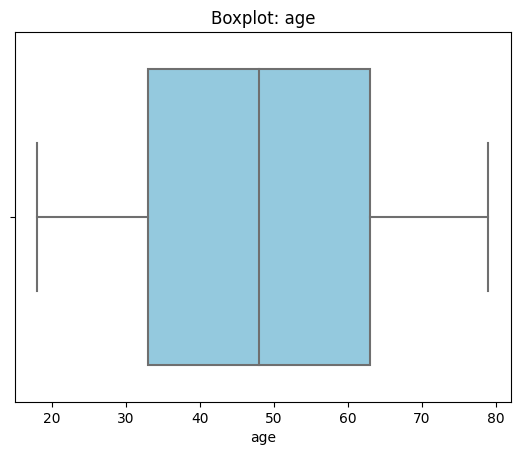

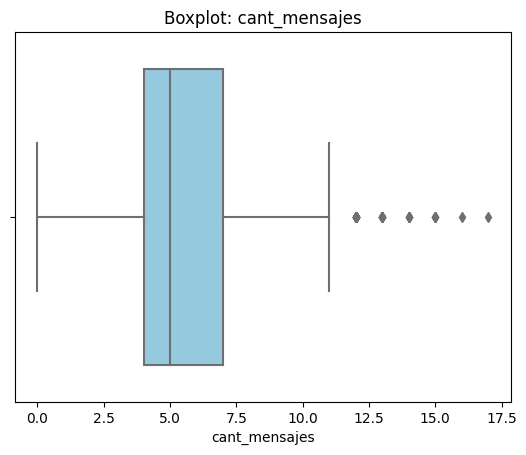

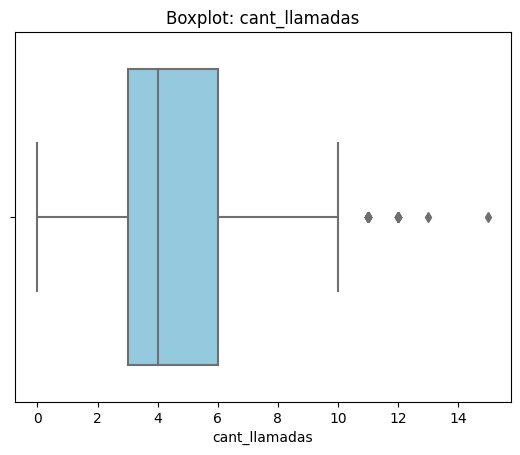

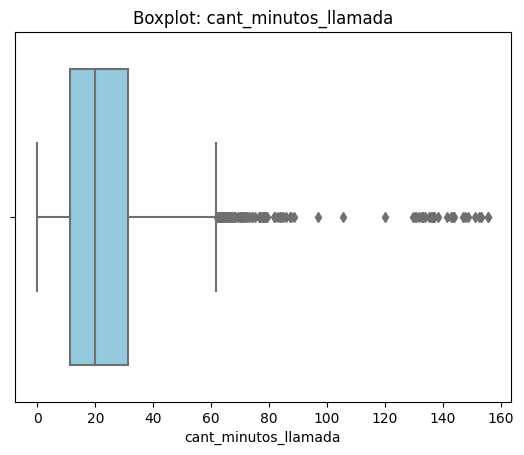

In [74]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 

- **age:** *no presenta outliers*. Todos los valores (18–79) están dentro de los bigotes y la mediana (48) está en el centro de la caja, lo que confirma una distribución simétrica.
- **cant_mensajes:** *presenta outliers solo del lado superior*: usuarios con 12 a 17 mensajes, por encima del bigote (11). Son pocos y están cerca del límite, por lo que parecen usuarios con uso alto pero realista.
- **cant_llamadas:** *presenta outliers solo del lado superior*: usuarios con 11 a 15 llamadas, por encima del bigote (10). También son pocos y con valores plausibles.
- **cant_minutos_llamada:** *presenta la mayor cantidad de outliers*, todos del lado superior (bigote en ~62 min). Se distinguen dos grupos:
  - Una concentración continua entre *62 y 90 minutos*, que corresponde a usuarios intensivos reales.
  - Un *grupo aislado entre 130 y 155 minutos*, separado del resto (con solo algunos puntos sueltos cerca de 97, 105 y 120). Este grupo coincide con los usuarios que tienen llamadas con el sentinel de 120 minutos, por lo que su consumo está inflado por un error de registro.

In [75]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    n_outliers = (user_profile[col] > limite_superior).sum()
    print(f'{col}: límite superior = {limite_superior:.2f} | outliers = {n_outliers}')

cant_mensajes: límite superior = 11.50 | outliers = 46
cant_llamadas: límite superior = 10.50 | outliers = 30
cant_minutos_llamada: límite superior = 61.86 | outliers = 109


In [76]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- **cant_mensajes: mantener los outliers.** El límite superior es 11.5 y el máximo 17; son 46 usuarios (1.2 %) con valores muy cercanos al límite y perfectamente posibles (12–17 mensajes en el periodo). No son errores, sino clientes con un uso de mensajes más alto que el promedio, un segmento útil para el análisis comercial.
- cant_llamadas: mantener o no outliers, porqué?
- **cant_llamadas: mantener los outliers.** El límite superior es 10.5 y el máximo 15; son 30 usuarios (0.75 %) con valores realistas (11–15 llamadas). Representan usuarios intensivos de llamadas, no errores de registro.
- cant_minutos_llamada: mantener o no outliers, porqué?
- - **cant_minutos_llamada: mantener, pero señalar los casos extremos.** El límite superior es 61.86 min y el máximo 155.69; hay 109 usuarios (2.7 %) por encima del límite. Se distinguen dos grupos:
  - **62–90 minutos:** usuarios intensivos reales, se conservan sin problema.
  - **130–155 minutos:** grupo aislado cuyo consumo está inflado por las llamadas con el sentinel de 120 minutos (error de registro).

  No se eliminan, para no perder el resto de su información (edad, plan, mensajes, llamadas). Para comparar segmentos se usará la mediana, que no se ve afectada por estos valores extremos. El grupo de 130–155 minutos se reporta como posible error de registro o comportamiento a investigar.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [77]:
# Crear columna grupo_uso

# 1. El cliente sin eventos registrados tiene 0 llamadas y 0 mensajes
user_profile['cant_mensajes'] = user_profile['cant_mensajes'].fillna(0)
user_profile['cant_llamadas'] = user_profile['cant_llamadas'].fillna(0)
user_profile['cant_minutos_llamada'] = user_profile['cant_minutos_llamada'].fillna(0)

# 2. Asignar 'Alto uso' a todos por defecto
user_profile['grupo_uso'] = 'Alto uso'

# 3. Uso medio: llamadas < 10 y mensajes < 10
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'

# 4. Bajo uso: llamadas < 5 y mensajes < 5
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

# Conteo por grupo
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

In [78]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [79]:
# Crear columna grupo_edad

# 1. Asignar 'Adulto Mayor' a todos por defecto
user_profile['grupo_edad'] = 'Adulto Mayor'

# 2. Adulto: age < 60
user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'

# 3. Joven: age < 30
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

# Conteo por grupo
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [80]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

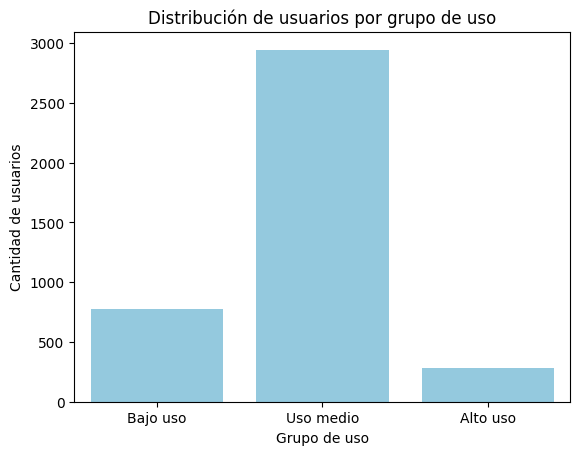

In [81]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso',
              order=['Bajo uso', 'Uso medio', 'Alto uso'],
              color='skyblue')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

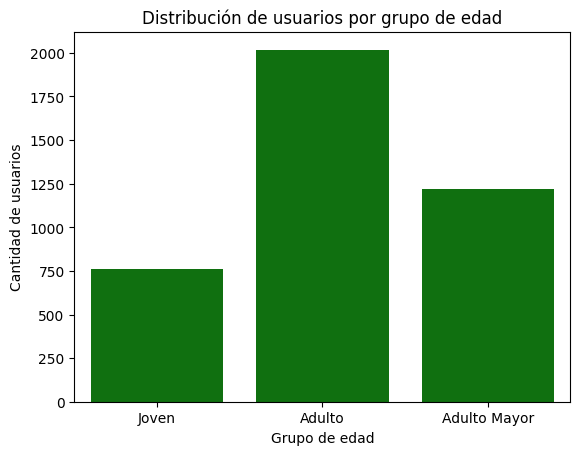

In [82]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              color='green')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- **`age`**: *55 registros (1.4 %)* con el sentinel -999, que distorsionaba la media (33.7 vs mediana 47). Se reemplazaron por la mediana de las edades válidas (48 años).
- **`city`**: *469 nulos (11.7 %)* más *96 registros con `"?"` (2.4 %)*; en total *565 clientes (14.1 %)* sin ciudad conocida. El `"?"` se convirtió en nulo.
- **`reg_date`**: *40 registros (1.0 %)* con una fecha imposible (2026-05-10, posterior al periodo de datos). Se marcaron como nulos (`NaT`).
- **`churn_date`**: *3,534 nulos (88.4 %)*; no es un error, sino que indica clientes activos.
- **`usage.date`**: *50 nulos (0.13 %)*; se dejaron como nulos por ser una proporción mínima.
- **`duration` (55.2 % nulos) y `length` (44.7 % nulos)**: nulos estructurales (MAR) que dependen de `type`, porque un mensaje no tiene duración y una llamada no tiene longitud. Se dejaron como nulos.
- **`duration`**: *30 llamadas* con el sentinel *120 min*; *`length`*: *30 mensajes* con el sentinel *1,490 caracteres*. Ambos son errores de registro.
- **1 cliente** sin ningún evento de uso; sus métricas se llenaron con 0.


🔍 **Segmentos por Edad**

- **Adultos (30–59 años): 2,018 clientes (50.4 %)**. Es el segmento más grande de la base y tiene la mayor proporción de alto uso (7.6 %).
- **Adultos Mayores (60+): 1,222 clientes (30.6 %)**. Es el grupo con mayor proporción de bajo uso (21 %).
- **Jóvenes (< 30): 760 clientes (19.0 %)**. Es el segmento más pequeño.
- **El comportamiento de uso es muy similar entre edades**: en los tres grupos ~73 % son de uso medio, y la proporción de planes Básico/Premium (~65/35) se mantiene igual. La edad, por sí sola, no diferencia el consumo.

📊 **Segmentos por Nivel de Uso**

- **Alto uso**: son los clientes más comprometidos con el servicio, pero también los que más abandonan, por lo que son prioritarios para retención.
- **Premium de bajo uso (266 clientes)**: generan el mayor margen, pero están en riesgo de bajar de plan o cancelar si perciben que pagan de más.
- **Adultos (50 % de la base)**: es el segmento con mayor volumen; cualquier mejora en su oferta tiene el mayor impacto.

**Segmentos más valiosos:**
- **Alto uso**: son los clientes más comprometidos con el servicio, pero también los que más abandonan, por lo que son prioritarios para retención.
- **Premium de bajo uso (266 clientes)**: generan el mayor margen, pero están en riesgo de bajar de plan o cancelar si perciben que pagan de más.
- **Adultos (50 % de la base)**: es el segmento con mayor volumen; cualquier mejora en su oferta tiene el mayor impacto.

**Outliers detectados:**
- **~30 usuarios con 130–155 minutos**: su consumo está inflado por llamadas con el sentinel de 120 minutos. Es un **error de registro**, no fraude ni uso real, y debe corregirse en el sistema de origen.
- **Usuarios intensivos reales** (12–17 mensajes, 11–15 llamadas, 62–90 minutos): son pocos (1–3 %) y representan clientes con mayor necesidad de servicio, no anomalías.

➡️ **Esto sugiere que** los planes actuales están *sobredimensionados*: un cliente típico usa ~20 minutos y ~5 mensajes en todo el periodo, mientras que el plan Básico incluye 100 minutos y 100 mensajes *al mes* (Premium, 600 y 500). Incluso el usuario de mayor consumo usa ~26 minutos al mes. Los clientes no eligen Premium por necesitar más llamadas o mensajes, por lo que su valor debe estar en otros beneficios (por ejemplo, datos).

💡 **Recomendaciones**

- **Crear un plan de entrada más económico** (por ejemplo, 30 minutos y 30 mensajes) para el segmento de *bajo uso* y adultos mayores, que capte clientes sensibles al precio y reduzca el riesgo de cancelación.
- **Reposicionar el plan Premium**: en lugar de competir por minutos y mensajes que nadie usa, diferenciarlo con *más GB de datos*, beneficios adicionales o servicios de valor agregado.
- **Campaña de retención para Premium de bajo uso (266 clientes)**: ofrecer beneficios que justifiquen el precio antes de que bajen de plan o cancelen.
- **Programa de fidelización para clientes de alto uso**: tienen el churn más alto (14 %); conviene ofrecerles incentivos de permanencia o beneficios exclusivos.
- **Corregir la captura de datos**: validar en el sistema de origen la edad, la ciudad y las fechas de registro, y revisar el registro de llamadas que guarda 120 minutos y mensajes de 1,490 caracteres por defecto.
- **Analizar el consumo de datos (GB)**: este análisis solo cubre llamadas y mensajes; incorporar el uso de datos móviles es clave para diseñar planes que reflejen el uso real.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`